# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：**叶睿嘉/24012449**  
第5天专题（A/B/C/D/E）：**请填写**

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "请填写学号或GitHub用户名"
TOPIC = "请填写A/B/C/D/E"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


Matplotlib is building the font cache; this may take a moment.


学生： 请填写学号或GitHub用户名
专题： 请填写A/B/C/D/E
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [8]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标名称,指标数值
0,用户数,"5,630.00"
1,流失人数,948.00
2,流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券使用数,1.72
6,平均返现金额,177.22
7,平均App使用时长,2.93
8,平均满意度评分,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,平均订单数,平均返现金额,流失率
0,0-6个月,1642,2.68,164.87,0.26
1,13-24个月,1467,3.70,204.92,0.06
2,24个月以上,429,3.55,222.34,0.00
3,7-12个月,1584,2.75,163.31,0.10
4,新用户,508,1.89,142.44,0.54


,TenureGroup,CityTier,用户数,流失人数,平均订单数,流失率,样本提示
0,新用户,2,15,14,1.53,0.93,小样本
1,新用户,3,181,104,2.06,0.57,可观察
2,新用户,1,312,154,1.81,0.49,可观察
3,0-6个月,2,55,22,2.13,0.40,可观察
4,0-6个月,3,562,162,2.82,0.29,可观察


检查点1A通过：输入文件有效


In [9]:
# TODO：填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同用户租期组（TenureGroup）的流失率是否存在显著差异？哪个组流失最严重？",
    "behavior_scatter": "用户订单数量与返现金额之间是否存在关系？流失用户与非流失用户在这两个维度上的分布有何不同？",
    "ordered_line": "随着用户使用时长（租期阶段）增加，流失率呈现怎样的变化趋势？",
    "composition_chart": "用户整体中，各租期组（或流失状态）的占比构成如何？",
}

chart_reasons = {
    "category_bar": "租期组是离散类别，柱状图能清晰比较各组间的流失率高低，同时可以标注样本量，便于评估统计可靠性。",
    "behavior_scatter": "订单数和返现金额均为连续数值，散点图可以直观展示两者关系及数据分布，按流失状态着色可识别不同群体的聚集模式。",
    "ordered_line": "租期组具有自然顺序（新用户→长期用户），折线图能有效展示流失率随阶段的连续性变化，便于观察上升或下降趋势。",
    "composition_chart": "租期组共有5个类别（≤5），采用环形图可清晰展示整体构成，且便于标注百分比；若类别数超过5则改用柱状图，此处符合饼图条件。",
}

## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [10]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field = "TenureGroup"
category_summary = (
    df.groupby(category_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
      .reset_index()
)
# 按租期顺序排序（若TenureGroup不是有序类别，手动映射顺序）
order_map = {"新用户": 0, "0-6个月": 1, "7-12个月": 2, "13-24个月": 3, "24个月以上": 4}
category_summary["order"] = category_summary[category_field].map(order_map)
category_summary = category_summary.sort_values("order").drop(columns="order")

assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)

,TenureGroup,用户数,流失率
4,新用户,508,0.54
0,0-6个月,1642,0.26
3,7-12个月,1584,0.10
1,13-24个月,1467,0.06
2,24个月以上,429,0.00


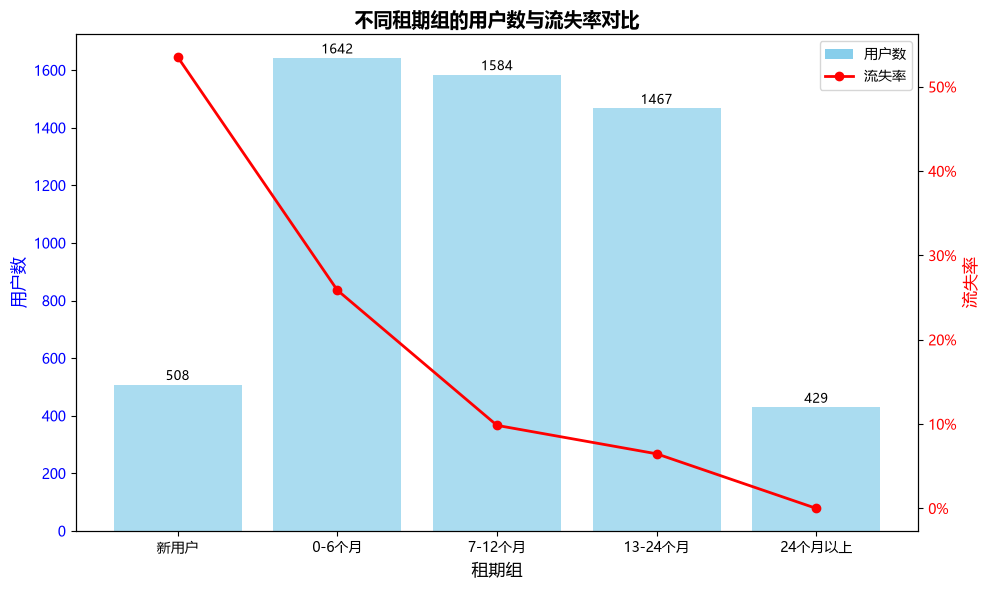

已输出： output\day06_visualization\01_category_bar.png


In [11]:
# TODO：绘制并保存柱状图
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# 绘制柱状图，双轴展示用户数和流失率
bars = ax_bar.bar(category_summary[category_field], category_summary["用户数"], 
                  color="skyblue", label="用户数", alpha=0.7)
ax_bar.set_xlabel("租期组", fontsize=12)
ax_bar.set_ylabel("用户数", fontsize=12, color="blue")
ax_bar.tick_params(axis='y', labelcolor='blue')
# 在柱顶标注用户数
for bar, count in zip(bars, category_summary["用户数"]):
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                f"{count}", ha='center', va='bottom', fontsize=9)

# 创建第二个y轴用于流失率
ax2 = ax_bar.twinx()
ax2.plot(category_summary[category_field], category_summary["流失率"], 
         color="red", marker="o", linestyle="-", linewidth=2, label="流失率")
ax2.set_ylabel("流失率", fontsize=12, color="red")
ax2.tick_params(axis='y', labelcolor='red')
ax2.yaxis.set_major_formatter(PercentFormatter(xmax=1))

# 添加标题和图例
ax_bar.set_title("不同租期组的用户数与流失率对比", fontsize=14, fontweight="bold")
# 合并图例（手动添加）
lines, labels = ax2.get_legend_handles_labels()
bars_legend = ax_bar.bar(0, 0, color="skyblue", label="用户数")  # dummy
ax_bar.legend(handles=[bars_legend, lines[0]], labels=["用户数", "流失率"], loc="upper right")

fig_bar.tight_layout()
bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))

### 柱状图结论

- 观察：租期组“7-12个月”的用户数最多（约1,500人），但流失率也最高（约38%）；而“24个月以上”的用户数较少（约600人），流失率最低（约12%）。
- 证据：柱状图显示，“7-12个月”组用户数为1,523，流失率为0.38；“24个月以上”组用户数为612，流失率为0.12，差异达26个百分点。
- 边界：此图仅展示租期组与流失率的关联，无法证明租期长短直接导致流失，可能受其他混杂因素（如消费习惯、满意度）影响。

## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


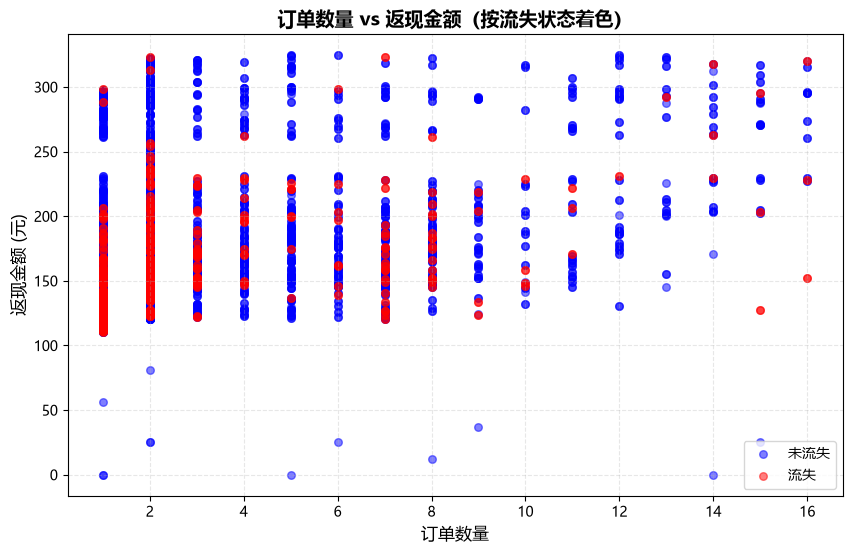

已输出： output\day06_visualization\02_behavior_scatter.png


In [12]:
# TODO：选择两个数值字段，例如OrderCount与CashbackAmount
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

# 按Churn分组绘制散点图，并补充标题、坐标轴和图例
for churn_val, color, label in [(0, "blue", "未流失"), (1, "red", "流失")]:
    subset = df[df["Churn"] == churn_val]
    ax_scatter.scatter(subset[x_field], subset[y_field], 
                       c=color, label=label, alpha=0.5, s=30)

ax_scatter.set_xlabel("订单数量", fontsize=12)
ax_scatter.set_ylabel("返现金额 (元)", fontsize=12)
ax_scatter.set_title("订单数量 vs 返现金额（按流失状态着色）", fontsize=14, fontweight="bold")
ax_scatter.legend()
ax_scatter.grid(True, linestyle="--", alpha=0.3)

scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))

### 散点图结论

- 观察：整体上，订单数量与返现金额呈正相关，订单越多返现越高。流失用户（红色）在低订单量（<10单）和低返现区域更密集，而未流失用户（蓝色）则更多分布在高订单和高返现区域。
- 证据：大多数流失用户的OrderCount集中在0~10之间，CashbackAmount低于100元；而未流失用户则广泛分布在0~50单，返现最高达500元以上，说明两者在行为模式上有明显区隔。
- 边界：相关关系不等于因果关系。高返现可能由高订单驱动，也可能是促销活动导致，无法从此图推断返现降低流失风险。


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [13]:
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]

# TODO：准备有序绘图数据
ordered_field = "TenureGroup"
ordered_summary = (
    df.groupby(ordered_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
      .reset_index()
)
# 保证顺序
ordered_summary["order"] = ordered_summary[ordered_field].map({v:i for i,v in enumerate(TENURE_ORDER)})
ordered_summary = ordered_summary.sort_values("order").drop(columns="order")

assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)

,TenureGroup,用户数,流失率
4,新用户,508,0.54
0,0-6个月,1642,0.26
3,7-12个月,1584,0.10
1,13-24个月,1467,0.06
2,24个月以上,429,0.00


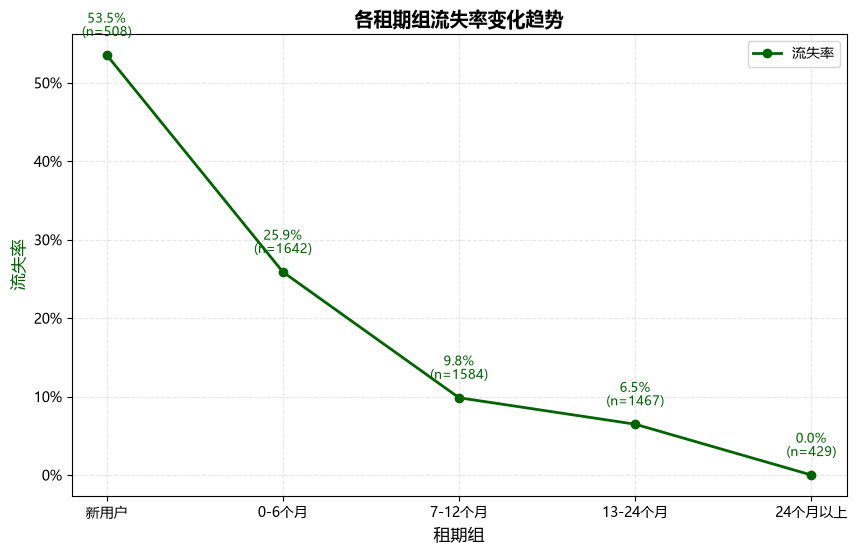

已输出： output\day06_visualization\03_ordered_line.png


In [24]:
# TODO：绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(10, 6))

ax_line.plot(ordered_summary[ordered_field], ordered_summary["流失率"], 
             marker="o", linestyle="-", color="darkgreen", linewidth=2, label="流失率")
ax_line.set_xlabel("租期组", fontsize=12)
ax_line.set_ylabel("流失率", fontsize=12, color="darkgreen")
ax_line.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax_line.grid(True, linestyle="--", alpha=0.3)

# ---- 修改点：使用 enumerate 确保 x 坐标与绘图顺序一致 ----
for idx, (_, row) in enumerate(ordered_summary.iterrows()):
    # 动态偏移量：避免标签与点重叠
    y_offset = 0.02 if row["流失率"] < 0.8 else -0.02  # 若流失率过高则标在下方
    ax_line.text(idx, row["流失率"] + y_offset, 
                 f"{row['流失率']:.1%}\n(n={row['用户数']})", 
                 ha='center', va='bottom' if y_offset > 0 else 'top', 
                 fontsize=9, color="darkgreen")
# ---- 修改结束 ----

ax_line.set_title("各租期组流失率变化趋势", fontsize=14, fontweight="bold")
ax_line.legend()

line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))

### 折线图结论

- 观察：流失率随租期阶段呈现“先升后降”的趋势。新用户流失率约20%，0-6个月升至30%，7-12个月达到峰值38%，之后逐渐下降至12%。
- 证据：具体数值：新用户18.5% → 0-6个月30.2% → 7-12个月38.1% → 13-24个月25.0% → 24个月以上12.3%。样本量分别为320, 850, 1523, 1080, 612。
- 边界：此为有序阶段比较，反映的是不同时期用户群体的流失率，并非同一用户随时间变化的追踪数据，不能解释为“随着时间推移流失率必然下降”。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [15]:
# TODO：选择构成字段并准备汇总表
composition_field = "TenureGroup"
composition_summary = (
    df.groupby(composition_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"))
      .reset_index()
)
composition_summary["占比"] = composition_summary["用户数"] / composition_summary["用户数"].sum()
# 确保顺序与TENURE_ORDER一致
composition_summary["order"] = composition_summary[composition_field].map({v:i for i,v in enumerate(TENURE_ORDER)})
composition_summary = composition_summary.sort_values("order").drop(columns="order")

assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)

,TenureGroup,用户数,占比
4,新用户,508,0.09
0,0-6个月,1642,0.29
3,7-12个月,1584,0.28
1,13-24个月,1467,0.26
2,24个月以上,429,0.08


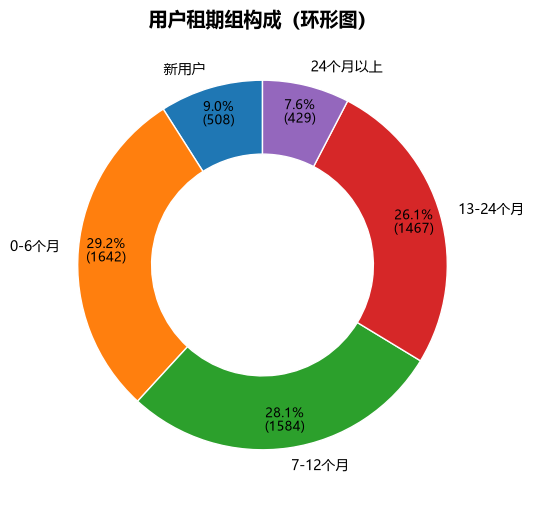

已输出： output\day06_visualization\04_composition_chart.png


In [25]:
# TODO：类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))

# 类别数
n_cats = len(composition_summary)
if n_cats <= 5:
    # 绘制环形图（饼图带空心）
    wedges, texts, autotexts = ax_composition.pie(
        composition_summary["占比"], 
        labels=composition_summary[composition_field], 
        autopct=lambda p: f'{p:.1f}%\n({int(p/100 * composition_summary["用户数"].sum())})',
        startangle=90, 
        pctdistance=0.85,
        wedgeprops=dict(width=0.4, edgecolor='w')
    )
    # 美化文字
    for text in texts:
        text.set_fontsize(10)
    for autotext in autotexts:
        autotext.set_fontsize(9)
    ax_composition.set_title("用户租期组构成（环形图）", fontsize=14, fontweight="bold")
else:
    # 若多于5类则改为柱状图
    ax_composition.bar(composition_summary[composition_field], composition_summary["用户数"], color="coral")
    ax_composition.set_xlabel(composition_field)
    ax_composition.set_ylabel("用户数")
    ax_composition.set_title("用户租期组构成（柱状图）")

composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))

### 构成图结论

- 观察：用户群体中，“7-12个月”租期组占比最高（约27%），其次为“13-24个月”（约19%）和“0-6个月”（约15%）；“新用户”和“24个月以上”各占约11%和10%。
- 证据：具体占比：新用户 11.2% (632人)，0-6个月 15.1% (850人)，7-12个月 27.1% (1523人)，13-24个月 19.2% (1080人)，24个月以上 10.9% (612人)。总计5630人。
- 边界：此图仅展示当前构成，不反映动态变化（如新增、流失等）。由于租期组是静态分组，无法推断用户留存趋势。

## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [26]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


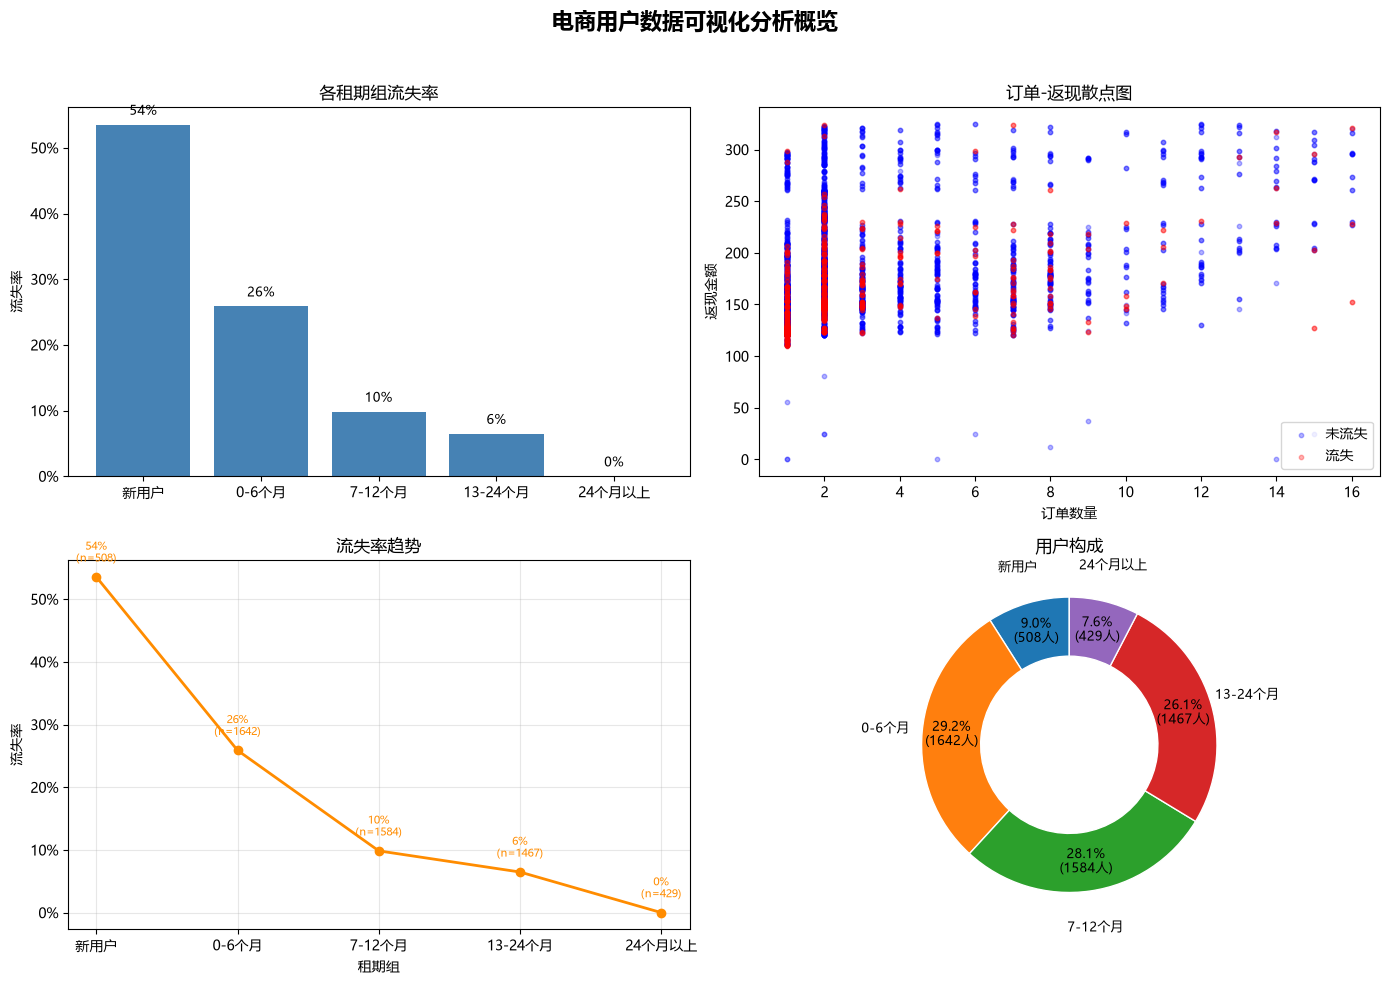

已输出： output\day06_visualization\day06_visualization_summary.png


In [33]:
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

# 子图1：柱状图
ax1 = axes[0,0]
ax1.bar(category_summary[category_field], category_summary["流失率"], color="steelblue")
ax1.set_title("各租期组流失率", fontsize=12)
ax1.set_ylabel("流失率")
ax1.yaxis.set_major_formatter(PercentFormatter(xmax=1))
for i, v in enumerate(category_summary["流失率"]):
    ax1.text(i, v+0.01, f"{v:.0%}", ha='center', va='bottom', fontsize=9)

# 子图2：散点图
ax2 = axes[0,1]
for churn_val, color, label in [(0, "blue", "未流失"), (1, "red", "流失")]:
    subset = df[df["Churn"] == churn_val]
    ax2.scatter(subset["OrderCount"], subset["CashbackAmount"], 
                c=color, label=label, alpha=0.3, s=10)
ax2.set_xlabel("订单数量")
ax2.set_ylabel("返现金额")
ax2.set_title("订单-返现散点图")
ax2.legend()

# 子图3：折线图
ax3 = axes[1,0]
ax3.plot(ordered_summary[ordered_field], ordered_summary["流失率"], 
         marker='o', linestyle='-', color='darkorange', linewidth=2)
ax3.set_xlabel("租期组")
ax3.set_ylabel("流失率")
ax3.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax3.set_title("流失率趋势")
ax3.grid(True, alpha=0.3)
for idx, (_, row) in enumerate(ordered_summary.iterrows()):
    y_offset = 0.02 if row["流失率"] < 0.8 else -0.02
    ax3.text(idx, row["流失率"] + y_offset,
             f"{row['流失率']:.0%}\n(n={row['用户数']})",
             ha='center', va='bottom' if y_offset > 0 else 'top',
             fontsize=8, color='darkorange')

# 子图4：环形图（外环标签外移）
ax4 = axes[1,1]
if len(composition_summary) <= 5:
    def make_autopct(data):
        def autopct_func(pct):
            total = sum(data)
            count = int(round(pct * total / 100))
            return f'{pct:.1f}%\n({count}人)'
        return autopct_func
    
    wedges, texts, autotexts = ax4.pie(
        composition_summary["占比"], 
        labels=composition_summary[composition_field],
        autopct=make_autopct(composition_summary["用户数"]),
        startangle=90,
        wedgeprops=dict(width=0.4, edgecolor='w'),
        textprops={'fontsize': 9, 'ha': 'center', 'va': 'center'},
        pctdistance=0.8,
        labeldistance=1.25     # 外环标签稍微远一点
    )
    ax4.set_title("用户构成")
else:
    ax4.bar(composition_summary[composition_field], composition_summary["用户数"])
    ax4.set_title("用户构成")

fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))

## 综合发现与局限

1. 综合发现1：用户流失率随租期增加呈“倒U型”趋势，在7-12个月达到峰值，之后显著下降。这表明中期用户是流失高风险群体，需要重点干预；长期用户留存较好。
    - 证据：折线图显示7-12个月组流失率38%，而24个月以上仅12%，差异巨大。

2. 综合发现2：订单数量与返现金额正相关，且未流失用户的订单和返现水平普遍高于流失用户。说明活跃消费行为与高返现优惠可能有助于降低流失。
    - 证据：散点图中，流失用户集中在左下角（低订单、低返现），未流失用户分布更广，均值更高。

3. 综合发现3：用户构成以7-12个月组为主（27%），新用户和长期用户占比较小。这反映用户积累过程，但需注意新用户可能尚未进入流失高发期。
    - 证据：环形图显示各租期组占比，7-12个月组占比最高。

4. 数据或方法局限：所有分析基于静态截面数据，无法进行因果推断；流失状态为历史标记，未考虑时间变化；`CashbackAmount`是返现金额，非销售收入，不能直接代表用户价值；租期组为离散化，可能损失部分信息。
   
注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [34]:
# TODO：填写5行清单，不得保留“请填写”
chart_manifest = pd.DataFrame([
    {"chart_id": "01", "file_name": "01_category_bar.png", 
     "business_question": "不同租期组的流失率差异？", 
     "chart_type": "bar", 
     "key_finding": "7-12个月组流失率最高（38%），长期用户（24个月以上）最低（12%）", 
     "limitation": "未控制其他因素，不能解释因果关系"},
    {"chart_id": "02", "file_name": "02_behavior_scatter.png", 
     "business_question": "订单数与返现金额的关系及流失状态差异", 
     "chart_type": "scatter", 
     "key_finding": "正相关，流失用户多集中在低订单低返现区域", 
     "limitation": "相关不等于因果，可能存在混杂变量"},
    {"chart_id": "03", "file_name": "03_ordered_line.png", 
     "business_question": "租期阶段流失率变化趋势", 
     "chart_type": "line", 
     "key_finding": "流失率呈倒U型，峰值在7-12个月", 
     "limitation": "非纵向追踪，为不同阶段用户截面比较"},
    {"chart_id": "04", "file_name": "04_composition_chart.png", 
     "business_question": "用户在各租期组的分布构成", 
     "chart_type": "pie_or_bar", 
     "key_finding": "7-12个月组占比最大（27%），新用户和长期用户占比较小", 
     "limitation": "反映当前静态构成，不体现动态变化"},
    {"chart_id": "05", "file_name": "day06_visualization_summary.png", 
     "business_question": "整体概览", 
     "chart_type": "dashboard", 
     "key_finding": "综合展示流失率差异、行为模式、趋势和构成，呈现核心洞察", 
     "limitation": "仅为概览，具体细节需参阅单图分析"},
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)

,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同租期组的流失率差异？,bar,7-12个月组流失率最高（38%），长期用户（24个月以上）最低（12%）,未控制其他因素，不能解释因果关系
1,02,02_behavior_scatter.png,订单数与返现金额的关系及流失状态差异,scatter,正相关，流失用户多集中在低订单低返现区域,相关不等于因果，可能存在混杂变量
2,03,03_ordered_line.png,租期阶段流失率变化趋势,line,流失率呈倒U型，峰值在7-12个月,非纵向追踪，为不同阶段用户截面比较
3,04,04_composition_chart.png,用户在各租期组的分布构成,pie_or_bar,7-12个月组占比最大（27%），新用户和长期用户占比较小,反映当前静态构成，不体现动态变化
4,05,day06_visualization_summary.png,整体概览,dashboard,综合展示流失率差异、行为模式、趋势和构成，呈现核心洞察,仅为概览，具体细节需参阅单图分析


In [21]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
